# Unit 7 Risk Modelling Activity 3: Revisiting the Pampered Pets Quantitative Model

Ian Stevens, Security and Risk Management, Unit 7.

My executive summary for Pampered Pets (Stevens, 2026) used three quantitative methods: a Monte Carlo simulation of product quality events, a fault tree for supply disruption, and a weighted sum model (WSM) to choose a cloud platform. It rejected Bayesian methods as 'complex' and 'data-hungry'. This notebook applies what I practised in the two activity notebooks to that work:

1. **Monte Carlo.** Rebuild the quality model, check it analytically, and ask what its confidence interval actually measures.
2. **Bayes.** Show how a small amount of test data could update one of its expert estimates, the probability that quality control detects a defect.
3. **Multi-criteria decision analysis.** Recheck the platform scores and test how sensitive the recommendation is to the weights and to the direction of one criterion.

All inputs in sections 1 and 3 are the figures published in the executive summary. The test data in section 2 are **hypothetical** and are labelled as such.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(2026)
os.makedirs("figures", exist_ok=True)   # saved copies of the charts
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 10)

In [2]:
# Plot style used for every figure in this unit
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, INK = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"

## 1. The Monte Carlo quality model

### 1.1 Rebuilding the model

The executive summary gave six inputs, each a triangular distribution (min, mode, max) for an annual probability, and three published results from 300,000 simulations. It did not set out how the inputs were combined, so I reconstructed the structure that reproduces the results:

* a **minor quality deviation** happens if any of a supplier deviation (SM), a data or inventory error (DE) or a cold-chain excursion (CC) happens;
* a **major quality failure** happens if a severe supplier defect (SS) or cyber-enabled data tampering (CT) happens **and quality control fails to detect it** (QD is the detection probability).

In [3]:
inputs = pd.DataFrame({
    "description": ["Supplier-related minor quality deviation", "Data or inventory integrity error",
                    "Cold-chain or handling excursion", "Severe supplier defect",
                    "Cyber-enabled data tampering", "Quality control detects defect"],
    "min": [0.06, 0.03, 0.02, 0.055, 0.035, 0.50],
    "mode": [0.09, 0.05, 0.04, 0.075, 0.055, 0.65],
    "max": [0.13, 0.08, 0.07, 0.11, 0.085, 0.85],
}, index=["P_SM", "P_DE", "P_CC", "P_SS", "P_CT", "P_QD"])
inputs["mean"] = (inputs["min"] + inputs["mode"] + inputs["max"]) / 3
inputs.round(4)

,description,min,mode,max,mean
P_SM,Supplier-related minor quality deviation,0.060,0.090,0.130,0.0933
P_DE,Data or inventory integrity error,0.030,0.050,0.080,0.0533
P_CC,Cold-chain or handling excursion,0.020,0.040,0.070,0.0433
P_SS,Severe supplier defect,0.055,0.075,0.110,0.0800
P_CT,Cyber-enabled data tampering,0.035,0.055,0.085,0.0583
P_QD,Quality control detects defect,0.500,0.650,0.850,0.6667


In [4]:
def tri(name, size):
    r = inputs.loc[name]
    return rng.triangular(r["min"], r["mode"], r["max"], size)

N = 300_000
p = {k: tri(k, N) for k in inputs.index}                        # one probability per simulated year
event = {k: rng.random(N) < p[k] for k in ["P_SM", "P_DE", "P_CC", "P_SS", "P_CT"]}
detect_ss = rng.random(N) < p["P_QD"]
detect_ct = rng.random(N) < p["P_QD"]

minor = event["P_SM"] | event["P_DE"] | event["P_CC"]
major = (event["P_SS"] & ~detect_ss) | (event["P_CT"] & ~detect_ct)
any_event = minor | major

def margin(x):
    return 1.96 * np.sqrt(x.mean() * (1 - x.mean()) / len(x))

mc = pd.DataFrame({
    "Published (exec. summary)": [0.178, 0.046, 0.216],
    "Rebuilt model": [minor.mean(), major.mean(), any_event.mean()],
    "95% margin (+/-)": [margin(minor), margin(major), margin(any_event)],
}, index=["Minor quality deviation", "Major quality failure", "Any quality event"])
mc.round(4)

,Published (exec. summary),Rebuilt model,95% margin (+/-)
Minor quality deviation,0.178,0.1779,0.0014
Major quality failure,0.046,0.0460,0.0007
Any quality event,0.216,0.2156,0.0015


The rebuilt model reproduces all three published figures, and its margins are close to the published intervals of ±0.13%, ±0.08% and ±0.15%, so I am confident this is the structure the executive summary used.

### 1.2 The same answer without simulation

In this model each simulated year draws a probability from a triangular distribution and then draws an event with that probability. For a single yes/no event, that two-step draw has exactly the same probability as using the **mean** of the triangular distribution, so the published figures can be calculated directly.

In [5]:
m = inputs["mean"]
minor_exact = 1 - (1 - m["P_SM"]) * (1 - m["P_DE"]) * (1 - m["P_CC"])

# The two undetected-defect events share the detection probability, so take the expectation over P_QD
q = inputs.loc["P_QD"]
miss_mean = 1 - m["P_QD"]
var_qd = (q["min"]**2 + q["mode"]**2 + q["max"]**2
          - q["min"]*q["mode"] - q["min"]*q["max"] - q["mode"]*q["max"]) / 18
miss_sq = var_qd + miss_mean**2                      # E[(1 - P_QD)^2]
major_exact = (m["P_SS"] + m["P_CT"]) * miss_mean - m["P_SS"] * m["P_CT"] * miss_sq
any_exact = 1 - (1 - minor_exact) * (1 - major_exact)

pd.DataFrame({"Simulated (300,000 runs)": [minor.mean(), major.mean(), any_event.mean()],
              "Exact": [minor_exact, major_exact, any_exact]},
             index=mc.index).round(4)

,"Simulated (300,000 runs)",Exact
Minor quality deviation,0.1779,0.1789
Major quality failure,0.0460,0.0456
Any quality event,0.2156,0.2163


The 300,000 simulations add nothing to a three-line calculation. More importantly, it shows that the ranges in the triangular distributions **never reach the output**: only their means do, apart from a negligible term where the two undetected-defect events share the same detection rate. The published ±0.13% is the Monte Carlo sampling error, which can be made as small as we like by running more simulations (see the dice game notebook). It is not a measure of how uncertain the estimate is.

### 1.3 Letting the input uncertainty through

To see how much the expert ranges matter, the model can be run in two stages. The outer loop draws one set of six probabilities (one 'possible world' consistent with the expert ranges); for each set the annual probabilities are then calculated exactly. The spread of the results across 20,000 sets shows what the ranges imply for the answer.

In [6]:
K = 20_000
d = {k: tri(k, K) for k in inputs.index}
miss = 1 - d["P_QD"]
minor_p = 1 - (1 - d["P_SM"]) * (1 - d["P_DE"]) * (1 - d["P_CC"])
major_p = 1 - (1 - d["P_SS"] * miss) * (1 - d["P_CT"] * miss)
any_p = 1 - (1 - minor_p) * (1 - major_p)

two_stage = pd.DataFrame({
    "Published point estimate": [0.178, 0.046, 0.216],
    "5th percentile": [np.percentile(x, 5) for x in (minor_p, major_p, any_p)],
    "Median": [np.median(x) for x in (minor_p, major_p, any_p)],
    "95th percentile": [np.percentile(x, 95) for x in (minor_p, major_p, any_p)],
}, index=mc.index)
two_stage.round(3)

,Published point estimate,5th percentile,Median,95th percentile
Minor quality deviation,0.178,0.150,0.179,0.209
Major quality failure,0.046,0.028,0.045,0.064
Any quality event,0.216,0.184,0.216,0.249


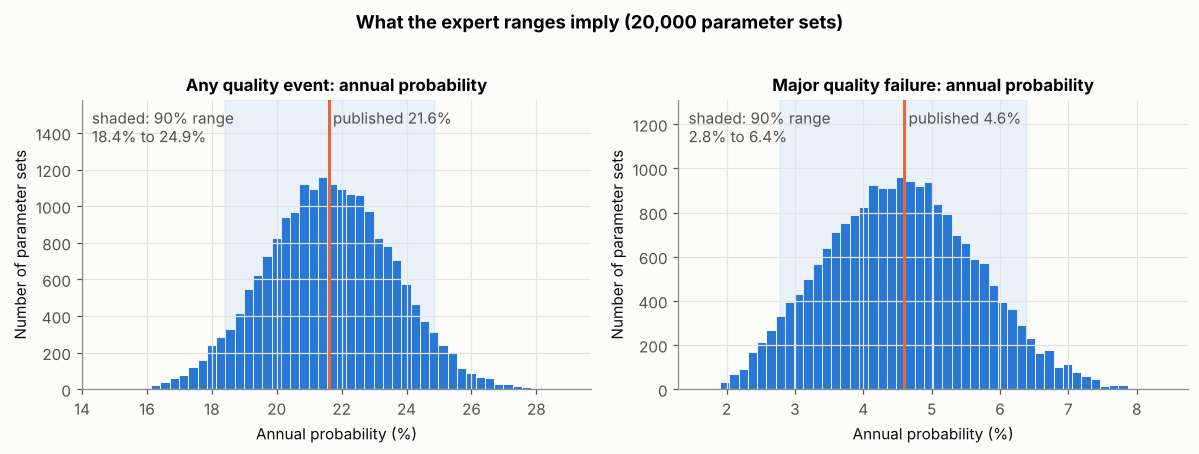

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for ax, x, pub, title in [(ax1, any_p, 0.216, "Any quality event"), (ax2, major_p, 0.046, "Major quality failure")]:
    ax.hist(x * 100, bins=50, color=BLUE, edgecolor="#fcfcfb", linewidth=0.6)
    lo, hi = np.percentile(x * 100, [5, 95])
    ax.axvspan(lo, hi, color=BLUE, alpha=0.08)
    ax.axvline(pub * 100, color=ORANGE, linewidth=2)
    top = ax.get_ylim()[1] * 1.3
    ax.set_ylim(0, top)
    ax.text(pub * 100, top * 0.97, f" published {pub:.1%}", color=INK, va="top")
    ax.text(0.02, 0.97, f"shaded: 90% range\n{lo:.1f}% to {hi:.1f}%", transform=ax.transAxes, color=INK, va="top")
    ax.set(title=f"{title}: annual probability", xlabel="Annual probability (%)", ylabel="Number of parameter sets")
fig.suptitle("What the expert ranges imply (20,000 parameter sets)", fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig("figures/u7_quality_uncertainty.png", dpi=150, bbox_inches="tight")

Taken at face value, the experts' own ranges put the annual chance of a major quality failure anywhere from about 2.8% to 6.4%, more than a factor of two, while the executive summary reported 4.6% ± 0.08%. The any-event figure is relatively less sensitive, roughly 18% to 25%, because it combines five independent inputs whose errors partly cancel.

Which input drives the uncertainty in a major failure? A rank correlation between each input and the result gives a simple answer.

In [8]:
drivers = pd.Series({k: stats.spearmanr(d[k], major_p).statistic for k in ["P_SS", "P_CT", "P_QD"]},
                    name="Rank correlation with P(major failure)")
drivers.round(2).to_frame()

,Rank correlation with P(major failure)
P_SS,0.32
P_CT,0.30
P_QD,-0.88


The detection probability matters most. Its range (50% to 85%) is the widest of the six inputs, and the miss rate it implies varies threefold, from 15% to 50%. That makes it the obvious estimate to improve with evidence, which is what section 2 does.

## 2. A Bayesian update of the detection rate

The executive summary rejected Bayesian methods as too data-hungry. A Bayesian *network* of the whole supply chain would be. But the simple Bayes table from Think Bayes chapter 2 needs only a prior and some evidence, and it is the natural way to improve one expert estimate.

**Hypothetical test.** Suppose Pampered Pets tested its quality control by passing 20 deliberately faulty sample batches through it, and QC caught 11. (These numbers are invented for illustration; no such test has been run.)

The hypotheses are possible values of the detection rate. I compare two priors:

* **Expert prior:** the triangular distribution from the executive summary, Tri(0.50, 0.65, 0.85).
* **Open prior:** every detection rate from 0 to 1 equally likely.

In [9]:
grid = np.linspace(0, 1, 1001)
caught, trials = 11, 20

def bayes_table(prior):
    table = pd.DataFrame(index=grid)
    table["prior"] = prior / prior.sum()
    table["likelihood"] = stats.binom.pmf(caught, trials, grid)
    table["unnorm"] = table["prior"] * table["likelihood"]
    table["posterior"] = table["unnorm"] / table["unnorm"].sum()
    return table

q = inputs.loc["P_QD"]
c = (q["mode"] - q["min"]) / (q["max"] - q["min"])
expert = bayes_table(stats.triang.pdf(grid, c, loc=q["min"], scale=q["max"] - q["min"]))
open_ = bayes_table(np.ones_like(grid))

def summarise(dist):
    cdf = dist.cumsum()
    return pd.Series({"mean": (grid * dist).sum(),
                      "5th percentile": grid[np.searchsorted(cdf, 0.05)],
                      "95th percentile": grid[np.searchsorted(cdf, 0.95)]})

pd.DataFrame({"Expert prior": summarise(expert["prior"]),
              "Posterior (expert prior)": summarise(expert["posterior"]),
              "Posterior (open prior)": summarise(open_["posterior"])}).round(3)

,Expert prior,Posterior (expert prior),Posterior (open prior)
mean,0.667,0.627,0.545
5th percentile,0.551,0.539,0.372
95th percentile,0.791,0.724,0.714


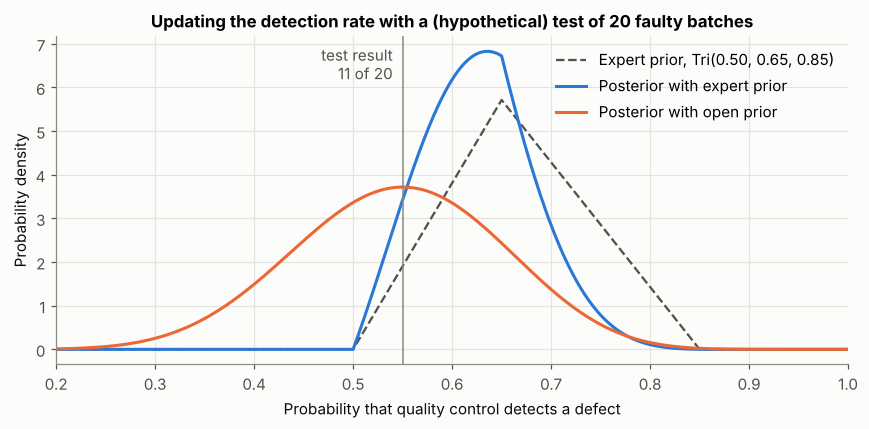

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid, expert["prior"] * 1000, color=INK, linestyle="--", linewidth=1.5, label="Expert prior, Tri(0.50, 0.65, 0.85)")
ax.plot(grid, expert["posterior"] * 1000, color=BLUE, label="Posterior with expert prior")
ax.plot(grid, open_["posterior"] * 1000, color=ORANGE, label="Posterior with open prior")
ax.axvline(caught / trials, color="#8a8984", linewidth=1)
ax.text(caught / trials - 0.01, ax.get_ylim()[1] * 0.97, "test result\n11 of 20", ha="right", va="top", color=INK)
ax.set(xlim=(0.2, 1.0), xlabel="Probability that quality control detects a defect", ylabel="Probability density",
       title="Updating the detection rate with a (hypothetical) test of 20 faulty batches")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
fig.savefig("figures/u7_detection_update.png", dpi=150, bbox_inches="tight")

Two things stand out. First, 20 trials are enough to move the estimate: with the expert prior the mean falls from 0.67 to 0.63 and the 95th percentile from 0.79 to 0.72. Twenty test batches is not a large data requirement. Second, the expert prior **cannot** go below 0.50, because a triangular distribution gives zero probability outside its bounds. With an open prior the test points to a detection rate somewhere around 0.37 to 0.71, so the evidence suggests the true rate could well be below the experts' minimum, and the expert prior silently rules that out. Bounded distributions are convenient, but a bound is a strong claim and should be justified like any other.

The final step feeds each posterior back into the major failure calculation, keeping the other inputs at their expert ranges.

In [11]:
def major_with(dist):
    qd = rng.choice(grid, size=K, p=dist.values)
    miss = 1 - qd
    return 1 - (1 - d["P_SS"] * miss) * (1 - d["P_CT"] * miss)

rows = {"Executive summary inputs": major_p,
        "Updated, expert prior": major_with(expert["posterior"]),
        "Updated, open prior": major_with(open_["posterior"])}
pd.DataFrame({k: {"mean": v.mean(), "5th percentile": np.percentile(v, 5),
                  "95th percentile": np.percentile(v, 95)} for k, v in rows.items()}).T.round(3)

,mean,5th percentile,95th percentile
Executive summary inputs,0.046,0.028,0.064
"Updated, expert prior",0.051,0.036,0.067
"Updated, open prior",0.062,0.037,0.088


If a test like this produced 11 detections out of 20, the expected chance of a major quality failure would rise from about 4.6% a year to about 5.1% with the expert prior and about 6.2% with the open prior, and the upper end of the open-prior range would reach almost 9%. Strengthening quality control would then look like a better investment than the executive summary suggested.

## 3. Rechecking the platform choice (MCDA)

### 3.1 Recalculating the weighted sum

The executive summary scored three cloud platforms from 1 to 5 on six weighted criteria.

In [12]:
weights = pd.Series({"Security & Compliance": 0.30, "Resilience & Availability": 0.25,
                     "RTO / RPO Capability": 0.15, "Operational Complexity": 0.10,
                     "Cost Transparency": 0.10, "Vendor Lock-In Risk": 0.10})
ratings = pd.DataFrame([[5, 4, 5, 4, 4, 4],
                        [4, 5, 5, 4, 4, 3],
                        [4, 4, 4, 4, 4, 3]],
                       index=["Microsoft Azure", "AWS", "Google Cloud"], columns=weights.index)
wsm = pd.DataFrame({"Published score": [4.35, 4.20, 3.85],
                    "Recalculated score": ratings @ weights})
wsm

,Published score,Recalculated score
Microsoft Azure,4.35,4.45
AWS,4.20,4.30
Google Cloud,3.85,3.90


Each published score is 0.05 to 0.10 too low. The ranking is unchanged, but the arithmetic in the executive summary was wrong.

### 3.2 Which way does 'vendor lock-in risk' point?

In a weighted sum every criterion must point the same way, with a higher rating meaning better. The table scores 'Vendor Lock-In Risk', and gives Azure the highest rating (4). If that rating measured the *amount* of risk, a higher rating would be worse and the scale would need reversing (6 minus the rating). The executive summary does not say which reading it intended.

In [13]:
reversed_ = ratings.copy()
reversed_["Vendor Lock-In Risk"] = 6 - reversed_["Vendor Lock-In Risk"]
pd.DataFrame({"Lock-in rating as benefit (higher = less lock-in)": ratings @ weights,
              "Lock-in rating as risk (higher = more lock-in)": reversed_ @ weights}).round(2)

,Lock-in rating as benefit (higher = less lock-in),Lock-in rating as risk (higher = more lock-in)
Microsoft Azure,4.45,4.25
AWS,4.30,4.30
Google Cloud,3.90,3.90


Read as a risk, the same ratings make **AWS** the recommendation (4.30 against 4.25). The platform choice depends on a labelling decision that the report never states, in a criterion worth only 10% of the weight.

### 3.3 How robust is the ranking to the weights?

The weights were my own judgements. To test them I drew 20,000 alternative weight sets from a Dirichlet distribution centred on the published weights (concentration 50, so each weight typically varies by a few percentage points) and recorded which platform came first each time.

In [14]:
alpha = 50 * weights.values
W = rng.dirichlet(alpha, size=20_000)

def share_first(r):
    scores = W @ r.T.values                       # 20,000 x 3
    winners = r.index[scores.argmax(axis=1)]
    return pd.Series(winners).value_counts(normalize=True).reindex(r.index, fill_value=0)

pd.DataFrame({"Lock-in as benefit": share_first(ratings),
              "Lock-in as risk": share_first(reversed_)}).round(3)

,Lock-in as benefit,Lock-in as risk
Microsoft Azure,0.912,0.328
AWS,0.088,0.672
Google Cloud,0.000,0.000


With lock-in read as a benefit, Azure comes first in about nine weight sets out of ten. With lock-in read as a risk, AWS comes first in about two thirds of them. Small changes in the weights matter less than how a criterion is defined.

### 3.4 Cross-check with TOPSIS

TOPSIS ranks alternatives by how close they sit to an ideal solution and how far from the worst. It uses the same weights and ratings but a different aggregation, so it is a quick check on whether the ranking is an artefact of the weighted sum.

In [15]:
def topsis(r, w, benefit):
    norm = r / np.sqrt((r**2).sum())
    v = norm * w
    best = np.where(benefit, v.max(), v.min())
    worst = np.where(benefit, v.min(), v.max())
    d_best = np.sqrt(((v - best)**2).sum(axis=1))
    d_worst = np.sqrt(((v - worst)**2).sum(axis=1))
    return d_worst / (d_best + d_worst)

benefit = np.array([True] * 6)
as_risk = np.array([True] * 5 + [False])
pd.DataFrame({"TOPSIS, lock-in as benefit": topsis(ratings, weights, benefit),
              "TOPSIS, lock-in as risk": topsis(ratings, weights, as_risk)}).round(3)

,"TOPSIS, lock-in as benefit","TOPSIS, lock-in as risk"
Microsoft Azure,0.587,0.540
AWS,0.467,0.512
Google Cloud,0.000,0.238


TOPSIS keeps Azure first under both readings, although its lead over AWS shrinks from 0.12 to 0.03. So with lock-in read as a risk, the two methods disagree: the weighted sum picks AWS and TOPSIS picks Azure. The recommendation therefore depends on two choices the executive summary did not discuss, the direction of one criterion and the aggregation method. Both methods share the deeper problem raised by Asadabadi, Chang and Saberi (2019): the inputs are coarse 1 to 5 judgements, and nearly every rating here is a 4, so a single point on one criterion can decide the outcome. MCDA makes the reasoning visible, which is its real value, but the result should be presented with its sensitivity, not as a precise score.

## References

Asadabadi, M.R., Chang, E. and Saberi, M. (2019) 'Are MCDM methods useful? A critical review of Analytic Hierarchy Process (AHP) and Analytic Network Process (ANP)', *Cogent Engineering*, 6(1), 1623153. Available at: https://doi.org/10.1080/23311916.2019.1623153

Downey, A.B. (2021) *Think Bayes: Bayesian statistics in Python*. 2nd edn. Sebastopol, CA: O'Reilly Media. Available at: https://allendowney.github.io/ThinkBayes2/

Stevens, I. (2026) *Quantitative risk assessment and digital resilience strategy for Pampered Pets: executive summary*. Unpublished assignment, Security and Risk Management module. University of Essex Online.